In [1]:
import sys
import os
 
# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/scaled.csv")
df.head()

,TransactionID,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSincePrev,AmountBalanceRatio,...,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,AccountID_freq,DeviceID_freq,IP Address_freq,MerchantID_freq,Location_freq
0,TX000001,-0.971275,2023-04-11 16:29:14,1.423718,-0.552443,-0.206794,-0.000537,2024-11-04 08:08:08,-0.800762,-0.386493,...,False,False,False,False,False,0.394950,0.780834,-1.059021,1.141666,-0.028446
1,TX000002,0.269440,2023-06-27 16:44:19,1.311287,0.305314,-0.206794,2.216472,2024-11-04 08:09:35,-0.076706,-0.338188,...,False,False,False,False,False,0.394950,0.235683,-0.568379,0.168981,0.598373
2,TX000003,-0.586882,2023-07-10 18:16:08,-1.443277,-0.909842,-0.206794,-1.023534,2024-11-04 08:07:04,0.046138,-0.171040,...,False,True,False,False,True,-0.936152,0.235683,0.903547,0.752592,0.284963
3,TX000004,-0.387456,2023-05-05 16:32:11,-1.049768,-1.353017,-0.206794,0.885797,2024-11-04 08:09:06,-0.575097,-0.349611,...,False,True,False,False,True,0.838651,0.780834,1.394189,0.947129,-0.028446
4,TX000005,-0.973468,2023-10-16 17:51:24,-1.049768,1.120184,-0.206794,0.593589,2024-11-04 08:06:39,0.967391,-0.388350,...,False,True,False,False,True,-0.048751,-0.854621,-0.568379,0.947129,0.284963


In [3]:
df = pd.read_csv("../data/processed/scaled.csv")

# Drop non-numeric and unwanted columns
df = df.drop(columns=[
    "TransactionID",
    "CustomerOccupation_Engineer",
    "CustomerOccupation_Retired",
    "TransactionDate",
    "Location_freq",
    "CustomerOccupation_Student",
    "PreviousTransactionDate"
], errors="ignore")

# Keep only numeric columns
df_numeric = df.select_dtypes(include=["int64", "float64", "bool"])

# Convert bool → int
df_numeric = df_numeric.astype(float)


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df_numeric)

print("Original shape:", df_numeric.shape)
print("PCA shape:", X_pca.shape)


Original shape: (2512, 16)
PCA shape: (2512, 13)


In [6]:
from src.clustering.hierarchical import HierarchicalClustering

hc = HierarchicalClustering(n_clusters=3, linkage_method="ward")
labels_hc = hc.fit(X_pca)

In [7]:
hc.plot_clusters(X_pca)

[INFO] Cluster plot saved to: ../results/hierarchical\hierarchical_ward_k3.png


In [8]:
hc.plot_dendrogram(X_pca)

[INFO] Dendrogram saved to: ../results/hierarchical\dendrogram_ward.png


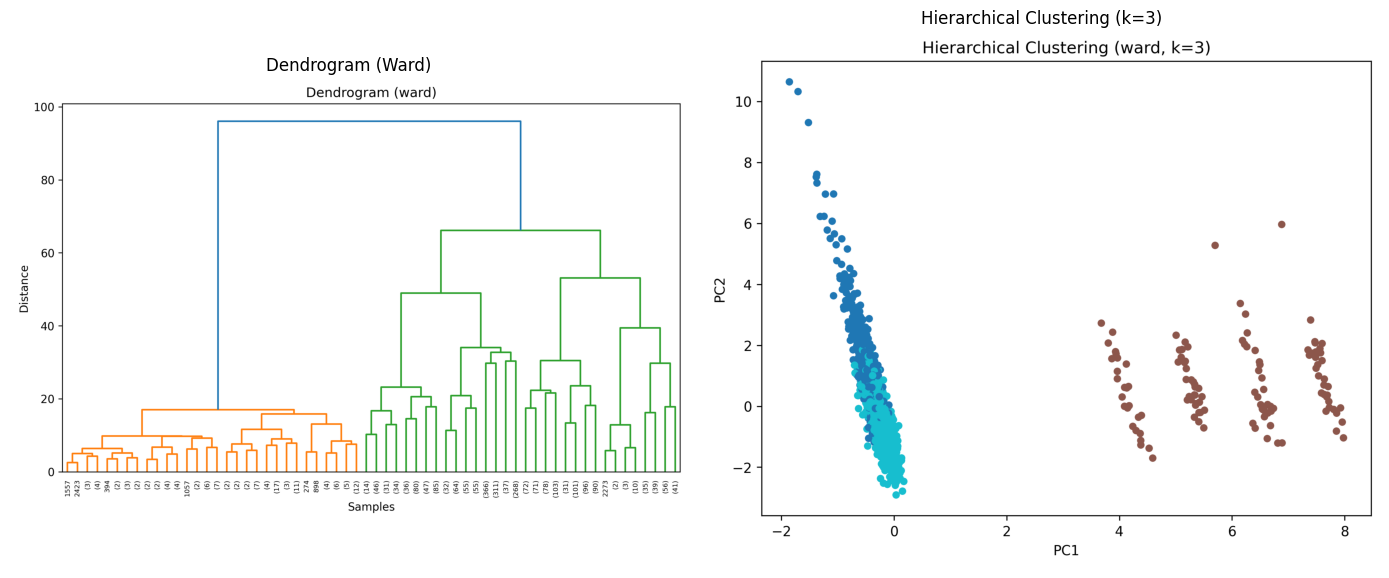

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Dendrogram
img1 = mpimg.imread("../results/hierarchical/dendrogram_ward.png")
axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("Dendrogram (Ward)")

# Right: Cluster Plot
img2 = mpimg.imread("../results/hierarchical/hierarchical_ward_k3.png")
axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("Hierarchical Clustering (k=3)")

plt.tight_layout()
plt.show()


In [10]:
labels_hc = hc.labels_

In [11]:
import numpy as np
import pandas as pd

unique, counts = np.unique(labels_hc, return_counts=True)
cluster_sizes = dict(zip(unique, counts))

cluster_sizes

{np.int64(0): np.int64(829),
 np.int64(1): np.int64(122),
 np.int64(2): np.int64(1561)}

In [20]:
import pandas as pd

# Build PCA dataframe with all components
pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_hc = pd.DataFrame(X_pca, columns=pca_cols)

# Add hierarchical cluster labels
df_hc["cluster"] = labels_hc

# Extract only row index + cluster for cluster 1
cluster_1_table = df_hc[df_hc["cluster"] == 1][["cluster"]]

cluster_1_table.head(10)


,cluster
23,1
26,1
32,1
38,1
61,1
91,1
117,1
147,1
167,1
231,1


In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# labels_hc must be your hierarchical cluster labels
# X_pca must be your PCA-transformed data

sil_hc = silhouette_score(X_pca, labels_hc)
dbi_hc = davies_bouldin_score(X_pca, labels_hc)
ch_hc = calinski_harabasz_score(X_pca, labels_hc)

print("Hierarchical Clustering Validation Metrics:")
print("Silhouette Score:", sil_hc)
print("Davies-Bouldin Index:", dbi_hc)
print("Calinski-Harabasz Score:", ch_hc)


Hierarchical Clustering Validation Metrics:
Silhouette Score: 0.11185052957102323
Davies-Bouldin Index: 2.429220900430888
Calinski-Harabasz Score: 322.2549668318385


## 📌 Hierarchical Clustering Anomaly Analysis (Ward, k=3)

Hierarchical clustering (Ward linkage, k=3) produced the following cluster sizes:

- **Cluster 0:** 829 points  
- **Cluster 1:** 122 points  
- **Cluster 2:** 1561 points  

The total dataset size is **2512**.

### 🔍 Identifying Anomalous Clusters
A common rule in cluster-based anomaly detection is that clusters smaller than **5% of the dataset** may represent anomalous or rare behavior.

- 5% threshold = 0.05 × 2512 = **125.6**

Since **Cluster 1 contains only 122 points**, which is **below the threshold**, it is identified as a **small anomaly cluster**.

This means Cluster 1 represents a minority pattern that differs from the dominant structure of the dataset.

---

## 📊 Validation Metrics

| Metric | Value | Interpretation |
|--------|--------|----------------|
| **Silhouette Score** | 0.1119 | Weak separation between clusters |
| **Davies–Bouldin Index** | 2.4292 | High overlap between clusters |
| **Calinski–Harabasz Score** | 322.25 | Moderate cluster structure |

### ✔ Interpretation
- The silhouette score indicates **weak cluster separation**, meaning the clusters are not very distinct in PCA space.
- The DBI value suggests **significant overlap** between clusters.
- The CH score shows **moderate structure**, but not strong.

Despite the weak global structure, the **small size of Cluster 1** still makes it a meaningful anomaly group.

---

## 🔎 Members of Cluster 1 (Examples)

Cluster 1 contains **122 points**.  
Sample rows:

| index | cluster |
|-------|---------|
| 23    | 1       |
| 26    | 1       |
| 32    | 1       |
| 38    | 1       |
| 61    | 1       |
| 91    | 1       |
| 117   | 1       |
| 147   | 1       |
| 167   | 1       |
| 231   | 1       |

These points belong to the **rare, minority cluster** and represent the hierarchical anomalies.

---

## ⭐ Final Interpretation

### ✔ Cluster 1 is the anomaly cluster  
- Smallest cluster (122 points)  
- Below the 5% anomaly threshold  
- Represents rare or unusual behavior in the dataset  

### ✔ Clusters 0 and 2 are normal clusters  
- Large, dense groups  
- Represent the dominant structure of the data  

### ✔ Hierarchical clustering reveals a **single, well-defined anomaly group**  
Even though the validation metrics show weak global separation, the **cluster size imbalance** clearly identifies Cluster 1 as the anomalous region.

---

## 🎯 Summary

Hierarchical clustering identifies:

- **1 anomaly cluster** → Cluster 1 (122 points)  
- **2 normal clusters** → Cluster 0 and Cluster 2  

Cluster 1 represents a minority pattern and is treated as the **hierarchical anomaly group**.
